# Fine-tuning:  — Final Evaluation (Dev Set)

Цель ноутбука — Провести **честное сравнение стратегий обучения** при фиксированных гиперпараметрах и одинаковых условиях.

Сравниваются:

- Scratch (обучение с нуля)
- Full fine-tuning (full_ft)
- Low LR encoder (low_lr_encoder)
- Partial fine-tuning (partial_ft)
- Warmup fine-tuning (warmup)

---

## ⚙️ Фиксированные условия

Все эксперименты проводятся при **одинаковых настройках**:

- `lr_encoder = 3e-5`
- `lr_head = 3e-4`
- `weight_decay = 1e-3`
- `warmup_epochs = 3`

Важно:
- ❗ **гиперпараметры НЕ подбираются**
- ❗ **split’ы фиксированы**
- ❗ **нормализация считается только по Calib_p субъекта**
- ❗ **test_rest не используется при обучении**

---

## 🧪 Протокол

Для каждого субъекта и каждого уровня калибровки:

\[
p \in \{10, 20, 40, 60, 100\}
\]

выполняется:

1. Формирование Calib_p (вложенные подвыборки)
2. Train/Val split внутри Calib_p (stratified)
3. Обучение модели
4. Early stopping по `val_loss`
5. Оценка на фиксированном `test_rest`

---

## 📊 Метрики

Для каждой конфигурации сохраняются:

- ROC-AUC (основная метрика)
- Accuracy
- Binary F1
- Precision / Recall
- FDR

---

## 🧠 Архитектура модели

- Encoder: `UNet1DEncoder`
- Head: Global Average Pooling (по времени) + Linear (512 → 2)
- Loss: CrossEntropy

---

## 🔄 Использование SSL

Рассматриваются два режима:

- **Scratch** — случайная инициализация encoder
- **SSL** — encoder предобучен (masked reconstruction на BigP3BCI)

---

## ⚠️ Важно про Dev-выборку

Этот ноутбук используется для:

- проверки стабильности pipeline
- sanity-check результатов
- анализа поведения стратегий

❗ Результаты на Dev **НЕ являются финальными**

Финальные выводы для диплома будут сделаны на **Test-выборке**, которая полностью отделена и не использовалась на этапе выбора стратегий и гиперпараметров.

---

## 📦 Ожидаемый результат

- Таблица: `p × strategy × metric`
- Графики:
  - ROC-AUC vs p
  - F1 vs p

---

## 🚀 Следующий шаг

После завершения данного этапа:

👉 аналогичный эксперимент будет проведён на **Test-выборке**  
👉 результаты Test будут использованы в дипломе как финальные

---


## 1. Импорты

In [1]:
import os
import json
import math
import random
import gc
from pathlib import Path
from copy import deepcopy
from itertools import product

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

## 2. Global config

In [2]:
CONFIG = {
    "seed": 42,
    
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "pin_memory": torch.cuda.is_available(),

    "data_root": Path("/kaggle/input/datasets/taisiyaglazova"),
    "encoder_checkpoint": Path("/kaggle/input/datasets/taisiyaglazova/ssl-full-encoder-best/encoder_best.pt"),
    "results_root": Path("/kaggle/working/stage5_block2_results"),

    "batch_size": 64,
    "num_workers": 2,

    "max_epochs": 100,
    "patience": 10,
    "min_delta": 0.0,

    "lr": 1e-4,
    "weight_decay": 1e-4,

    "fallback_p_for_zero": 10,
    "val_ratio": 0.2,

    "p_list": [0, 10, 20, 40, 60, 100],
    "scenarios": ["scratch", "ssl_ft"],

    "save_predictions": True,
    "save_history": True,
}

In [3]:
# Выходные папки
(CONFIG["results_root"] / "history").mkdir(parents=True, exist_ok=True)
(CONFIG["results_root"] / "predictions").mkdir(parents=True, exist_ok=True)
(CONFIG["results_root"] / "checkpoints").mkdir(parents=True, exist_ok=True)
(CONFIG["results_root"] / "logs").mkdir(parents=True, exist_ok=True)

## 3. Воспроизводимость

In [4]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [5]:
set_seed(CONFIG["seed"])
print("Device:", CONFIG["device"])

Device: cuda


## 4. Пути

In [6]:
# Пути к датасетам
DATASETS = {
    "bigp3_train": CONFIG["data_root"] / "bigp3bci-downstream-train",
    "bigp3_benchmark": CONFIG["data_root"] / "bigp3bci-downstream-benchmark",
    "bcicomp3": CONFIG["data_root"] / "bcicompiii-ds2",  
}

In [7]:
GROUPS = ["train", "benchmark", "bcicomp3"]

In [8]:
# Универсальные функции путей
def get_epochs_path(subject_id: str, group: str) -> Path:
    assert group in GROUPS, f"Unknown group: {group}"

    if group == "train":
        path = DATASETS["bigp3_train"] / "train" / f"{subject_id}.npz"
    elif group == "benchmark":
        path = DATASETS["bigp3_benchmark"]/ "benchmark" / f"{subject_id}.npz"
    elif group == "bcicomp3":
        path = DATASETS["bcicomp3"] / "epochs" / f"{subject_id}_train_epochs_v1.npz"
    
    return path


def get_split_path(subject_id: str, group: str) -> Path:
    assert group in GROUPS, f"Unknown group: {group}"

    if group == "train":
        path = DATASETS["bigp3_train"] / "splits" / "train" / f"{subject_id}.json"
    elif group == "benchmark":
        path = DATASETS["bigp3_benchmark"] / "splits" / "benchmark" / f"{subject_id}.json"
    elif group == "bcicomp3":
        path = DATASETS["bcicomp3"] / "splits" / f"{subject_id}_time30_seed42_v1.json"
        
    return path


def get_stats_path(subject_id: str, p: int, group: str) -> Path:
    assert group in GROUPS, f"Unknown group: {group}"

    if group == "train":
        path = DATASETS["bigp3_train"] / "stats" / "train" / f"{subject_id}_p{p}.npz"
    elif group == "benchmark":
        path = DATASETS["bigp3_benchmark"] / "stats" / "benchmark" / f"{subject_id}_p{p}.npz"
    elif group == "bcicomp3":
        path = DATASETS["bcicomp3"] / "stats" / f"{subject_id}_time30_seed42_p{p}_v1.npz"
        
    return path

In [9]:
# Автореестр субъектов
def list_subject_ids(group: str):
    assert group in GROUPS, f"Unknown group: {group}"

    if group == "train":
        data_dir = DATASETS["bigp3_train"] / "train"
    elif group == "benchmark":
        data_dir = DATASETS["bigp3_benchmark"]/ "benchmark"

    subject_ids = sorted([p.stem for p in data_dir.glob("*.npz")])
    return subject_ids

In [10]:
# Сборка реестра
SUBJECT_REGISTRY = {
    "train": list_subject_ids("train"),
    "benchmark": list_subject_ids("benchmark"),
}

print("Train subjects:", len(SUBJECT_REGISTRY["train"]))
print("Benchmark subjects:", len(SUBJECT_REGISTRY["benchmark"]))
print("Example train:", SUBJECT_REGISTRY["train"][:5])
print("Example benchmark:", SUBJECT_REGISTRY["benchmark"][:5])


Train subjects: 93
Benchmark subjects: 65
Example train: ['subj_000', 'subj_001', 'subj_002', 'subj_003', 'subj_004']
Example benchmark: ['subj_051', 'subj_052', 'subj_053', 'subj_054', 'subj_055']


In [11]:
# Валидация существования файлов
def check_subject_files(subject_id: str, group: str, p_list=(10, 20, 40, 60, 100)):
    report = {
        "epochs": get_epochs_path(subject_id, group).exists(),
        "split": get_split_path(subject_id, group).exists(),
        "stats": {p: get_stats_path(subject_id, p, group).exists() for p in p_list},
    }
    return report

example_subj = SUBJECT_REGISTRY["train"][80]
check_subject_files(example_subj, "train")

{'epochs': True,
 'split': True,
 'stats': {10: True, 20: True, 40: True, 60: True, 100: True}}

## Конфиг для full Dev run

In [12]:
FINAL_DEV_CONFIG = {
    "subjects": SUBJECT_REGISTRY["train"],   # или твой Dev-список, если он уже зафиксирован отдельно
    "group": "train",
    "p_list": [0, 10, 20, 40, 60, 100],
    "ft_strategy_list": ["full_ft", "low_lr_encoder", "partial_ft", "warmup"],
    "seed_list": [42],

    "lr_encoder": 3e-5,
    "lr_head": 3e-4,
    "weight_decay": 1e-3,
    "warmup_epochs": 3,
}

In [13]:
FINAL_DEV_TAG = "stage5_final_eval_dev_ft_strategies"
FINAL_DEV_DIR = Path(CONFIG["results_root"]) / FINAL_DEV_TAG

In [14]:
FINAL_DEV_DIR.mkdir(parents=True, exist_ok=True)
print("FINAL_DEV_DIR:", FINAL_DEV_DIR)

FINAL_DEV_DIR: /kaggle/working/stage5_block2_results/stage5_final_eval_dev_ft_strategies


## 5. Core data I/O

In [15]:
# Загрузка эпох
def load_subject_epochs(subject_id: str, group: str):
    path = get_epochs_path(subject_id, group)
    if not path.exists():
        raise FileNotFoundError(f"Epochs file not found: {path}")

    data = np.load(path, allow_pickle=True)

    if "X" not in data or "y" not in data:
        raise KeyError(f"{path} must contain keys 'X' and 'y'. Found: {list(data.keys())}")

    X = data["X"]
    y = data["y"]

    return X, y

In [16]:
# Загрузка split
def load_subject_split(subject_id: str, group: str):
    path = get_split_path(subject_id, group)
    if not path.exists():
        raise FileNotFoundError(f"Split file not found: {path}")

    with open(path, "r", encoding="utf-8") as f:
        split = json.load(f)

    # Приводим формат bcicomp3 к стандартному формату pipeline
    if group == "bcicomp3":
        if "indices" not in split:
            raise KeyError("bcicomp3 split must contain top-level key 'indices'")

        idx = split["indices"]

        normalized_split = {
            "calib_pool_idx": idx["calib_pool_idx"],
            "test_rest_idx": idx["test_rest_idx"],
            "calib_idx": idx["calib_idx"],
        }
        return normalized_split

    return split

In [17]:
# Загрузка stats
def load_subject_stats(subject_id: str, p: int, group: str):
    path = get_stats_path(subject_id, p, group)
    if not path.exists():
        raise FileNotFoundError(f"Stats file not found: {path}")

    data = np.load(path, allow_pickle=True)

    if "mean" not in data or "std" not in data:
        raise KeyError(f"{path} must contain keys 'mean' and 'std'. Found: {list(data.keys())}")

    mean = data["mean"]
    std = data["std"]

    return mean, std

In [18]:
# Объединённая загрузка bundle
def load_subject_bundle(subject_id: str, p: int, group: str):
    X, y = load_subject_epochs(subject_id, group)
    split = load_subject_split(subject_id, group)

    mean, std = (None, None)
    if p > 0:
        mean, std = load_subject_stats(subject_id, p, group)

    bundle = {
        "subject_id": subject_id,
        "group": group,
        "p": p,
        "X": X,
        "y": y,
        "split": split,
        "mean": mean,
        "std": std,
    }
    return bundle

## Split внутри Calib_p

In [19]:
# Функции для извлечения индексов
def get_test_indices(split: dict) -> np.ndarray:
    """
    Возвращает индексы test_rest в глобальной индексации subject-level X/y.
    """
    if "test_rest_idx" not in split:
        raise KeyError("split must contain 'test_rest_idx'")
    return np.asarray(split["test_rest_idx"], dtype=np.int64)


def get_calib_pool_indices(split: dict) -> np.ndarray:
    """
    Возвращает индексы calib_pool в глобальной индексации subject-level X/y.
    """
    if "calib_pool_idx" not in split:
        raise KeyError("split must contain 'calib_pool_idx'")
    return np.asarray(split["calib_pool_idx"], dtype=np.int64)


def get_calib_indices(split: dict, p: int) -> np.ndarray:
    """
    Возвращает индексы calib_p в глобальной индексации subject-level X/y.

    Для p=0 возвращает пустой массив.
    """
    if p == 0:
        return np.asarray([], dtype=np.int64)

    if "calib_idx" not in split:
        raise KeyError("split must contain 'calib_idx'")

    calib_idx_dict = split["calib_idx"]

    if not isinstance(calib_idx_dict, dict):
        raise TypeError(f"split['calib_idx'] must be dict, got {type(calib_idx_dict)}")

    if str(p) not in calib_idx_dict:
        raise KeyError(
            f"p={p} not found in split['calib_idx']; available keys: {list(calib_idx_dict.keys())}"
        )

    return np.asarray(calib_idx_dict[str(p)], dtype=np.int64)


def make_train_val_split(
    calib_idx: np.ndarray,
    y: np.ndarray,
    val_ratio: float = 0.2,
    seed: int = 42,
    stratify: bool = True,
):
    """
    Делит calib_idx на train_idx и val_idx.

    Все индексы остаются глобальными относительно X/y конкретного subject.
    """
    calib_idx = np.asarray(calib_idx, dtype=np.int64)

    if len(calib_idx) == 0:
        return (
            np.asarray([], dtype=np.int64),
            np.asarray([], dtype=np.int64),
        )

    if len(calib_idx) < 2:
        raise ValueError("calib_idx must contain at least 2 samples")

    y_calib = y[calib_idx]
    stratify_labels = y_calib if stratify else None

    try:
        train_idx, val_idx = train_test_split(
            calib_idx,
            test_size=val_ratio,
            random_state=seed,
            shuffle=True,
            stratify=stratify_labels,
        )
    except ValueError as e:
        print(f"[WARN] Stratified split failed: {e}")
        print("[WARN] Falling back to non-stratified split.")
        train_idx, val_idx = train_test_split(
            calib_idx,
            test_size=val_ratio,
            random_state=seed,
            shuffle=True,
            stratify=None,
        )

    return (
        np.asarray(train_idx, dtype=np.int64),
        np.asarray(val_idx, dtype=np.int64),
    )


def prepare_run_indices(
    split: dict,
    y: np.ndarray,
    p: int,
    val_ratio: float = 0.2,
    seed: int = 42,
):
    """
    Готовит все индексы для одного запуска.

    Возвращает словарь:
    - calib_pool_idx
    - calib_idx
    - train_idx
    - val_idx
    - test_idx
    """
    calib_pool_idx = get_calib_pool_indices(split)
    test_idx = get_test_indices(split)
    calib_idx = get_calib_indices(split, p)

    calib_pool_set = set(calib_pool_idx.tolist())
    test_set = set(test_idx.tolist())
    calib_set = set(calib_idx.tolist())

    # test и calib_pool не должны пересекаться
    if len(calib_pool_set & test_set) > 0:
        raise ValueError("calib_pool_idx intersects with test_rest_idx")

    # calib_p должен быть подмножеством calib_pool
    if len(calib_set) > 0 and not calib_set.issubset(calib_pool_set):
        raise ValueError("calib_idx is not a subset of calib_pool_idx")

    if p == 0:
        train_idx = np.asarray([], dtype=np.int64)
        val_idx = np.asarray([], dtype=np.int64)
    else:
        train_idx, val_idx = make_train_val_split(
            calib_idx=calib_idx,
            y=y,
            val_ratio=val_ratio,
            seed=seed,
            stratify=True,
        )

    return {
        "calib_pool_idx": calib_pool_idx,
        "calib_idx": calib_idx,
        "train_idx": train_idx,
        "val_idx": val_idx,
        "test_idx": test_idx,
    }

## Нормализация и нарезка данных по индексам

In [20]:
# Фукции нормализации
def safe_standardize(X: np.ndarray, mean: np.ndarray, std: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    """
    Поканальная z-нормализация массива X формы (N, C, L)
    по mean/std формы (C,).
    """
    X = np.asarray(X, dtype=np.float32)
    mean = np.asarray(mean, dtype=np.float32)
    std = np.asarray(std, dtype=np.float32)

    if X.ndim != 3:
        raise ValueError(f"X must have shape (N, C, L), got {X.shape}")
    if mean.ndim != 1 or std.ndim != 1:
        raise ValueError(f"mean/std must have shape (C,), got mean={mean.shape}, std={std.shape}")
    if X.shape[1] != len(mean) or X.shape[1] != len(std):
        raise ValueError(
            f"Channel mismatch: X has C={X.shape[1]}, mean={len(mean)}, std={len(std)}"
        )

    std_safe = np.maximum(std, eps)
    X_norm = (X - mean[None, :, None]) / std_safe[None, :, None]
    return X_norm.astype(np.float32)


def get_effective_stats(bundle: dict, subject_id: str, group: str, p: int, fallback_p_for_zero: int = 10):
    """
    Возвращает mean/std для данного запуска.
    
    Для p>0 используются stats именно этого p.
    Для p=0 используются fallback-статистики, например p=10.
    """
    if p > 0:
        mean = bundle["mean"]
        std = bundle["std"]
    else:
        mean, std = load_subject_stats(subject_id, fallback_p_for_zero, group)

    if mean is None or std is None:
        raise ValueError(f"Stats are not available for subject={subject_id}, group={group}, p={p}")

    return mean, std

In [21]:
# Функции нарезки по индексам
def slice_by_indices(X: np.ndarray, y: np.ndarray, idx: np.ndarray):
    """
    Возвращает подмножество X/y по глобальным индексам subject-level массива.
    """
    idx = np.asarray(idx, dtype=np.int64)

    if len(idx) == 0:
        X_empty = np.empty((0, X.shape[1], X.shape[2]), dtype=np.float32)
        y_empty = np.empty((0,), dtype=y.dtype)
        return X_empty, y_empty

    return X[idx], y[idx]


def prepare_indexed_arrays(
    bundle: dict,
    indices_dict: dict,
    fallback_p_for_zero: int = 10,
):
    """
    Подготавливает нормализованные массивы:
    - X_train, y_train
    - X_val, y_val
    - X_test, y_test

    bundle должен содержать:
    - subject_id
    - group
    - p
    - X
    - y
    - mean/std (если p>0)
    """
    subject_id = bundle["subject_id"]
    group = bundle["group"]
    p = bundle["p"]

    X = bundle["X"]
    y = bundle["y"]

    mean, std = get_effective_stats(
        bundle=bundle,
        subject_id=subject_id,
        group=group,
        p=p,
        fallback_p_for_zero=fallback_p_for_zero,
    )

    X_norm = safe_standardize(X, mean, std)

    X_train, y_train = slice_by_indices(X_norm, y, indices_dict["train_idx"])
    X_val, y_val = slice_by_indices(X_norm, y, indices_dict["val_idx"])
    X_test, y_test = slice_by_indices(X_norm, y, indices_dict["test_idx"])

    return {
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
        "X_test": X_test,
        "y_test": y_test,
        "mean": mean,
        "std": std,
    }

## 6. Dataset / DataLoader

In [22]:
class EEGDataset(Dataset):
    """
    Простой Dataset для EEG-эпох.
    X: np.ndarray формы (N, C, L)
    y: np.ndarray формы (N,)
    """
    def __init__(self, X: np.ndarray, y: np.ndarray):
        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y)

        if X.ndim != 3:
            raise ValueError(f"X must have shape (N, C, L), got {X.shape}")
        if y.ndim != 1:
            raise ValueError(f"y must have shape (N,), got {y.shape}")
        if len(X) != len(y):
            raise ValueError(f"Length mismatch: len(X)={len(X)}, len(y)={len(y)}")

        self.X = X
        self.y = y.astype(np.int64)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.X[idx])      # float32, shape (C, L)
        y = torch.tensor(self.y[idx], dtype=torch.long)
        return x, y

In [23]:
def make_loader(
    X: np.ndarray,
    y: np.ndarray,
    batch_size: int,
    shuffle: bool,
    num_workers: int = 0,
    pin_memory: bool = True,
):
    """
    Создаёт DataLoader для заданных X/y.
    Если массив пустой, возвращает None.
    """
    if len(y) == 0:
        return None

    dataset = EEGDataset(X, y)

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=pin_memory,
        drop_last=False,
    )
    return loader

In [24]:
def build_loaders(
    arrays_dict: dict,
    batch_size: int = 64,
    num_workers: int = 0,
    pin_memory: bool = True,
):
    """
    По словарю prepared arrays создаёт:
    - train_loader
    - val_loader
    - test_loader

    Для p=0 train/val будут None.
    """
    train_loader = make_loader(
        X=arrays_dict["X_train"],
        y=arrays_dict["y_train"],
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )

    val_loader = make_loader(
        X=arrays_dict["X_val"],
        y=arrays_dict["y_val"],
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )

    test_loader = make_loader(
        X=arrays_dict["X_test"],
        y=arrays_dict["y_test"],
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )

    return {
        "train_loader": train_loader,
        "val_loader": val_loader,
        "test_loader": test_loader,
    }

## 7. Определение модели

In [25]:
class DoubleConv1D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Down1D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.MaxPool1d(kernel_size=2, stride=2),
            DoubleConv1D(in_channels, out_channels)
        )

    def forward(self, x):
        return self.block(x)


class Up1D(nn.Module):
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()
        self.bilinear = bilinear

        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode="linear", align_corners=True)
            mid_channels = in_channels // 2
            self.conv = DoubleConv1D(in_channels, out_channels)
        else:
            self.up = nn.ConvTranspose1d(in_channels, out_channels, kernel_size=2, stride=2)
            self.conv = DoubleConv1D(in_channels, out_channels)

    def forward(self, x1, x2):
        # x1: низ, x2: skip
        x1 = self.up(x1)

        # подгоняем длину, если не совпадает
        diff = x2.size(-1) - x1.size(-1)
        if diff > 0:
            x1 = nn.functional.pad(x1, (diff // 2, diff - diff // 2))
        elif diff < 0:
            x2 = nn.functional.pad(x2, (-diff // 2, -diff - (-diff // 2)))

        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv1D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


class UNet1D_Light(nn.Module):
    """
    U-Net 1D с 4 уровнями даунсемплинга, вдохновлён Hong et al., 2025.
    Каналы: 32 → 64 → 128 → 256, bottleneck 512.
    """
    def __init__(self, n_channels, n_classes, base_ch=32, bilinear=True):
        super().__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        ch1 = base_ch
        ch2 = base_ch * 2
        ch3 = base_ch * 4
        ch4 = base_ch * 8
        bottleneck_ch = base_ch * 16  # 512 при base_ch=32

        # encoder
        self.inc = DoubleConv1D(n_channels, ch1)
        self.down1 = Down1D(ch1, ch2)
        self.down2 = Down1D(ch2, ch3)
        self.down3 = Down1D(ch3, ch4)
        self.down4 = Down1D(ch4, bottleneck_ch)

        # decoder
        self.up1 = Up1D(bottleneck_ch + ch4, ch4, bilinear)
        self.up2 = Up1D(ch4 + ch3, ch3, bilinear)
        self.up3 = Up1D(ch3 + ch2, ch2, bilinear)
        self.up4 = Up1D(ch2 + ch1, ch1, bilinear)
        self.outc = OutConv1D(ch1, n_classes)

    def encode(self, x):
        x1 = self.inc(x)     # (N, ch1, L)
        x2 = self.down1(x1)  # (N, ch2, L/2)
        x3 = self.down2(x2)  # (N, ch3, L/4)
        x4 = self.down3(x3)  # (N, ch4, L/8)
        x5 = self.down4(x4)  # (N, bottleneck_ch, L/16)
        return x1, x2, x3, x4, x5

    def decode(self, x1, x2, x3, x4, x5):
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

    def forward(self, x):
        x1, x2, x3, x4, x5 = self.encode(x)
        logits = self.decode(x1, x2, x3, x4, x5)
        return logits, x5  # x5 — bottleneck

class UNet1DEncoder(nn.Module):
    """
    Обёртка над encoder-частью обученного U-Net.
    На вход:  x ∈ R^{B×C×L}
    На выход: bottleneck-фичи x5 ∈ R^{B×C_bottleneck×L_reduced}
    """
    def __init__(self, unet_model: nn.Module):
        super().__init__()
        # просто переиспользуем уже обученные блоки
        self.inc = unet_model.inc
        self.down1 = unet_model.down1
        self.down2 = unet_model.down2
        self.down3 = unet_model.down3
        self.down4 = unet_model.down4

    def forward(self, x):
        # это ровно то, что делал encode() в полном U-Net
        x1 = self.inc(x)    # (B, ch1, L)
        x2 = self.down1(x1) # (B, ch2, L/2)
        x3 = self.down2(x2) # (B, ch3, L/4)
        x4 = self.down3(x3) # (B, ch4, L/8)
        x5 = self.down4(x4) # (B, bottleneck_ch, L/16)
        return x5

class ERPHead(nn.Module):
    """
    Минимальная классификационная голова для P300.
    Вход:  (B, F, T)
    Выход: (B, 2) logits
    """
    def __init__(self, in_features=512, num_classes=2):
        super().__init__()
        self.fc = nn.Linear(in_features, num_classes)

    def forward(self, z):
        # z: (B, F, T)
        z = z.mean(dim=-1)   # global average pooling → (B, F)
        logits = self.fc(z)  # (B, 2)
        return logits
    
class P300Model(nn.Module):
    """
    Полная downstream модель:
    x → encoder → head → logits
    """
    def __init__(self, encoder, head):
        super().__init__()
        self.encoder = encoder
        self.head = head

    def forward(self, x):
        z = self.encoder(x)
        logits = self.head(z)
        return logits

In [26]:
# Загрузка весов
def load_encoder_checkpoint_into_model_encoder(model_encoder: nn.Module, encoder_checkpoint: str, device: str = "cpu"):
    """
    Загружает encoder_best.pt в encoder downstream-модели.

    Ожидаемый формат checkpoint:
    {
        'inc': state_dict(...),
        'down1': state_dict(...),
        'down2': state_dict(...),
        'down3': state_dict(...),
        'down4': state_dict(...),
    }
    """
    ckpt = torch.load(encoder_checkpoint, map_location=device)

    expected_keys = ["inc", "down1", "down2", "down3", "down4"]
    missing = [k for k in expected_keys if k not in ckpt]
    if len(missing) > 0:
        raise KeyError(f"Encoder checkpoint is missing keys: {missing}. Found keys: {list(ckpt.keys())}")

    model_encoder.inc.load_state_dict(ckpt["inc"], strict=True)
    model_encoder.down1.load_state_dict(ckpt["down1"], strict=True)
    model_encoder.down2.load_state_dict(ckpt["down2"], strict=True)
    model_encoder.down3.load_state_dict(ckpt["down3"], strict=True)
    model_encoder.down4.load_state_dict(ckpt["down4"], strict=True)

    return model_encoder

In [27]:
def build_model(
    scenario: str,
    device: str,
    encoder_checkpoint: str = None,
):
    """
    Собирает downstream-модель для сценариев:
    - scratch
    - ssl_ft

    scratch:
        encoder случайный

    ssl_ft:
        encoder той же архитектуры + загруженные SSL-веса

    head всегда создаётся заново
    """
    valid_scenarios = {"scratch", "ssl_ft"}
    if scenario not in valid_scenarios:
        raise ValueError(f"Unknown scenario: {scenario}. Expected one of {valid_scenarios}")

    # создаём базовый U-Net только как контейнер encoder-блоков
    unet = UNet1D_Light(
        n_channels=14,
        n_classes=14,
        base_ch=32,
        bilinear=True,
    )
    encoder = UNet1DEncoder(unet)

    if scenario == "ssl_ft":
        if encoder_checkpoint is None:
            raise ValueError("encoder_checkpoint must be provided for scenario='ssl_ft'")
        encoder = load_encoder_checkpoint_into_model_encoder(
            model_encoder=encoder,
            encoder_checkpoint=encoder_checkpoint,
            device=device,
        )

    head = ERPHead(in_features=512, num_classes=2)
    model = P300Model(encoder=encoder, head=head)
    model = model.to(device)

    return model

In [28]:
# Счётчик параметров
def count_all_parameters(model: nn.Module):
    return sum(p.numel() for p in model.parameters())


def count_trainable_parameters(model: nn.Module):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## Поддержка 4 FT-сценариев

In [29]:
# ============================================================
# FT scenario helpers: freeze / unfreeze / optimizer groups
# ============================================================

import torch
import torch.nn as nn


def set_requires_grad(module: nn.Module, flag: bool) -> None:
    """Set requires_grad for all parameters in a module."""
    for p in module.parameters():
        p.requires_grad = flag


def freeze_all(model: nn.Module) -> None:
    """Freeze all model parameters."""
    for p in model.parameters():
        p.requires_grad = False


def apply_trainable_mode(model: nn.Module, trainable_mode: str) -> None:
    """
    Configure which parts of the model are trainable.

    Expected model structure:
        model.encoder.inc
        model.encoder.down1
        model.encoder.down2
        model.encoder.down3
        model.encoder.down4
        model.head
    """
    freeze_all(model)

    if trainable_mode == "full":
        set_requires_grad(model.encoder, True)
        set_requires_grad(model.head, True)

    elif trainable_mode == "down4_only":
        set_requires_grad(model.encoder.down4, True)
        set_requires_grad(model.head, True)

    elif trainable_mode == "head_only":
        set_requires_grad(model.head, True)

    else:
        raise ValueError(f"Unknown trainable_mode: {trainable_mode}")


def get_trainable_parameter_names(model: nn.Module):
    """Return names of trainable parameters."""
    return [name for name, p in model.named_parameters() if p.requires_grad]


def count_parameters(model: nn.Module):
    """Count total and trainable parameters."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def build_ft_optimizer(
    model: nn.Module,
    scenario_name: str,
    lr_encoder: float,
    lr_head: float,
    weight_decay: float,
):
    """
    Build AdamW optimizer according to FT scenario config.

    Scenarios:
        - full_ft
        - low_lr_encoder
        - partial_ft
        - warmup
    """
    scenario_cfg = SCENARIO_CONFIGS[scenario_name]

    encoder_params = [p for p in model.encoder.parameters() if p.requires_grad]
    head_params = [p for p in model.head.parameters() if p.requires_grad]

    if not encoder_params and not head_params:
        raise ValueError("No trainable parameters found.")

    if scenario_cfg["use_discriminative_lr"]:
        param_groups = []
        if encoder_params:
            param_groups.append({
                "params": encoder_params,
                "lr": lr_encoder,
                "weight_decay": weight_decay,
            })
        if head_params:
            param_groups.append({
                "params": head_params,
                "lr": lr_head,
                "weight_decay": weight_decay,
            })
        optimizer = torch.optim.AdamW(param_groups)

    else:
        all_trainable = [p for p in model.parameters() if p.requires_grad]
        optimizer = torch.optim.AdamW(
            all_trainable,
            lr=lr_head,
            weight_decay=weight_decay,
        )

    return optimizer


def summarize_trainable_parameters(model: nn.Module, max_lines: int = 50) -> None:
    """Print a short summary of trainable parameters."""
    total, trainable = count_parameters(model)
    names = get_trainable_parameter_names(model)

    print(f"Total params     : {total:,}")
    print(f"Trainable params : {trainable:,}")
    print(f"Frozen params    : {total - trainable:,}")
    print(f"Trainable tensors: {len(names)}")

    preview = names[:max_lines]
    if preview:
        print("\nTrainable parameter names:")
        for name in preview:
            print(" -", name)

    if len(names) > max_lines:
        print(f"... and {len(names) - max_lines} more")

## 8. Training / evaluation 

In [30]:
def train_one_epoch(model, loader, optimizer, criterion, device: str):
    """
    Одна эпоха обучения.
    Возвращает средний loss по эпохе.
    """
    if loader is None:
        raise ValueError("train loader is None")

    model.train()

    running_loss = 0.0
    n_samples = 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()

        batch_size = xb.size(0)
        running_loss += loss.item() * batch_size
        n_samples += batch_size

    epoch_loss = running_loss / max(n_samples, 1)
    return epoch_loss


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device: str):
    """
    Одна эпоха валидации.
    Возвращает средний loss по эпохе.
    """
    if loader is None:
        raise ValueError("val loader is None")

    model.eval()

    running_loss = 0.0
    n_samples = 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        logits = model(xb)
        loss = criterion(logits, yb)

        batch_size = xb.size(0)
        running_loss += loss.item() * batch_size
        n_samples += batch_size

    epoch_loss = running_loss / max(n_samples, 1)
    return epoch_loss

In [31]:
# training history
def init_history():
    return {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
    }


def append_history(history: dict, epoch: int, train_loss: float, val_loss: float):
    history["epoch"].append(epoch)
    history["train_loss"].append(float(train_loss))
    history["val_loss"].append(float(val_loss))
    return history

In [32]:
# цикл обучения
def fit_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device: str,
    max_epochs: int = 100,
    patience: int = 10,
    min_delta: float = 0.0,
    verbose: bool = True,
):
    """
    Train/val цикл с early stopping по val_loss.

    Возвращает словарь с:
    - history
    - best_epoch
    - best_val_loss
    - best_state_dict
    - stopped_epoch
    """
    if train_loader is None:
        raise ValueError("train_loader is None")
    if val_loader is None:
        raise ValueError("val_loader is None")

    history = init_history()
    early_stopper = EarlyStopping(
        patience=patience,
        min_delta=min_delta,
        mode="min",
    )

    stopped_epoch = max_epochs

    for epoch in range(1, max_epochs + 1):
        train_loss = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device,
        )

        val_loss = validate_one_epoch(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device,
        )

        append_history(history, epoch, train_loss, val_loss)

        early_stopper.step(val_loss, model, epoch)

        if verbose:
            msg = (
                f"epoch {epoch:03d} | "
                f"train_loss={train_loss:.6f} | "
                f"val_loss={val_loss:.6f} | "
                f"best_val={early_stopper.best_value:.6f} @ epoch {early_stopper.best_epoch}"
            )
            print(msg)

        if early_stopper.should_stop:
            stopped_epoch = epoch
            if verbose:
                print(f"Early stopping triggered at epoch {epoch}.")
            break

    result = {
        "history": history,
        "best_epoch": early_stopper.best_epoch,
        "best_val_loss": early_stopper.best_value,
        "best_state_dict": early_stopper.best_state_dict,
        "stopped_epoch": stopped_epoch,
    }
    return result

In [33]:
# Optimizer и Loss

## Старый build_optimizer
# def build_optimizer(model, lr: float, weight_decay: float):
#     return torch.optim.AdamW(
#         filter(lambda p: p.requires_grad, model.parameters()),
#         lr=lr,
#         weight_decay=weight_decay,
#     )


def build_criterion(y_train=None):
    if y_train is None:
        return nn.CrossEntropyLoss()

    n_pos = (y_train == 1).sum()
    n_neg = (y_train == 0).sum()

    weight_pos = n_neg / (n_pos + 1e-8)

    class_weights = torch.tensor([1.0, weight_pos], dtype=torch.float32)

    return nn.CrossEntropyLoss(weight=class_weights.to(CONFIG["device"]))
    

In [34]:
# Загрузка best state
def load_best_model_state(model: nn.Module, fit_result: dict):
    """
    Загружает best_state_dict обратно в модель.
    """
    best_state_dict = fit_result.get("best_state_dict", None)
    if best_state_dict is None:
        raise ValueError("fit_result does not contain 'best_state_dict'")
    model.load_state_dict(best_state_dict)
    return model

## 10. Early stopping / checkpoint utilities

In [35]:
class EarlyStopping:
    """
    Early stopping по val_loss.

    mode='min' означает, что метрика должна уменьшаться.
    """
    def __init__(self, patience: int = 10, min_delta: float = 0.0, mode: str = "min"):
        if mode not in {"min", "max"}:
            raise ValueError("mode must be 'min' or 'max'")

        self.patience = patience
        self.min_delta = float(min_delta)
        self.mode = mode

        self.best_value = None
        self.best_epoch = None
        self.best_state_dict = None
        self.counter = 0
        self.should_stop = False

    def _is_improvement(self, value: float) -> bool:
        if self.best_value is None:
            return True

        if self.mode == "min":
            return value < (self.best_value - self.min_delta)
        else:
            return value > (self.best_value + self.min_delta)

    def step(self, value: float, model: nn.Module, epoch: int):
        """
        Обновляет состояние early stopping после очередной эпохи.
        """
        if self._is_improvement(value):
            self.best_value = float(value)
            self.best_epoch = int(epoch)
            self.best_state_dict = deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

## Test prediction и метрики

In [36]:
# prediction на loader
@torch.no_grad()
def predict_on_loader(model, loader, device: str):
    """
    Прогоняет модель по loader и возвращает:
    - y_true
    - prob_score   : probability of positive class
    - logit_score  : raw logit of positive class
    - y_pred       : threshold=0.5 on prob_score
    """
    if loader is None:
        raise ValueError("loader is None")

    model.eval()

    all_y = []
    all_prob = []
    all_logit = []
    all_pred = []

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)

        logits = model(xb)                    # (B, 2)
        probs = torch.softmax(logits, dim=1)  # (B, 2)

        prob_score = probs[:, 1]
        logit_score = logits[:, 1]
        pred = (prob_score >= 0.5).long()

        all_y.append(yb.numpy())
        all_prob.append(prob_score.cpu().numpy())
        all_logit.append(logit_score.cpu().numpy())
        all_pred.append(pred.cpu().numpy())

    y_true = np.concatenate(all_y) if len(all_y) > 0 else np.array([], dtype=np.int64)
    prob_score = np.concatenate(all_prob) if len(all_prob) > 0 else np.array([], dtype=np.float32)
    logit_score = np.concatenate(all_logit) if len(all_logit) > 0 else np.array([], dtype=np.float32)
    y_pred = np.concatenate(all_pred) if len(all_pred) > 0 else np.array([], dtype=np.int64)

    return {
        "y_true": y_true,
        "prob_score": prob_score,
        "logit_score": logit_score,
        "y_pred": y_pred,
    }

In [37]:
## FDR
def compute_fisher_fdr(y_true: np.ndarray, score: np.ndarray):
    """
    Fisher's Discriminant Ratio:
        FDR = (mu_pos - mu_neg)^2 / (var_pos + var_neg)

    score должен быть непрерывным classifier score.
    """
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score).astype(float)

    pos_scores = score[y_true == 1]
    neg_scores = score[y_true == 0]

    if len(pos_scores) == 0 or len(neg_scores) == 0:
        return np.nan

    mu_pos = np.mean(pos_scores)
    mu_neg = np.mean(neg_scores)

    var_pos = np.var(pos_scores)
    var_neg = np.var(neg_scores)

    denom = var_pos + var_neg
    if denom <= 0:
        return np.nan

    return float((mu_pos - mu_neg) ** 2 / denom)

In [38]:
# accuracy, f1, precision, recall, fdr
def compute_metrics(
    y_true: np.ndarray,
    prob_score: np.ndarray,
    logit_score: np.ndarray,
    y_pred: np.ndarray,
):
    """
    Считает метрики в соответствии с логикой статьи:
    - AUC: по probability score
    - Accuracy: по binary predictions
    - F1: по binary predictions
    - Precision/Recall: по binary predictions
    - FDR: Fisher's Discriminant Ratio по classifier score
    """
    y_true = np.asarray(y_true).astype(int)
    prob_score = np.asarray(prob_score).astype(float)
    logit_score = np.asarray(logit_score).astype(float)
    y_pred = np.asarray(y_pred).astype(int)

    metrics = {}

    if len(np.unique(y_true)) < 2:
        metrics["auc"] = np.nan
    else:
        metrics["auc"] = float(roc_auc_score(y_true, prob_score))

    metrics["accuracy"] = float(accuracy_score(y_true, y_pred))
    metrics["f1"] = float(f1_score(y_true, y_pred, zero_division=0))
    metrics["precision"] = float(precision_score(y_true, y_pred, zero_division=0))
    metrics["recall"] = float(recall_score(y_true, y_pred, zero_division=0))
    metrics["fdr"] = compute_fisher_fdr(y_true, logit_score)

    return metrics

In [39]:
# Объединяющая функия test evaluation
def evaluate_on_test(model, test_loader, device: str):
    pred_dict = predict_on_loader(
        model=model,
        loader=test_loader,
        device=device,
    )

    metrics = compute_metrics(
        y_true=pred_dict["y_true"],
        prob_score=pred_dict["prob_score"],
        logit_score=pred_dict["logit_score"],
        y_pred=pred_dict["y_pred"],
    )

    return {
        "predictions": pred_dict,
        "metrics": metrics,
    }

## Подбор порога

In [40]:
def select_best_threshold(y_true, prob_score, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.40, 71)

    best_t = 0.5
    best_f1 = -1.0

    for t in grid:
        y_pred = (prob_score >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = float(t)

    return best_t, best_f1

In [41]:
# Подсчёт метрик с заданным порогом
def compute_metrics_with_threshold(y_true, prob_score, logit_score, threshold):
    y_pred = (prob_score >= threshold).astype(int)
    return compute_metrics(
        y_true=y_true,
        prob_score=prob_score,
        logit_score=logit_score,
        y_pred=y_pred,
    )

## FT training wrappers

In [42]:
def train_standard_ft(
    model,
    train_loader,
    val_loader,
    criterion,
    device,
    scenario_name: str,
    lr_encoder: float,
    lr_head: float,
    weight_decay: float,
    max_epochs: int,
    patience: int,
    min_delta: float,
):
    """
    Standard FT training for:
        - full_ft
        - low_lr_encoder
        - partial_ft
    """
    scenario_cfg = SCENARIO_CONFIGS[scenario_name]

    apply_trainable_mode(model, scenario_cfg["trainable_mode"])

    optimizer = build_ft_optimizer(
        model=model,
        scenario_name=scenario_name,
        lr_encoder=lr_encoder,
        lr_head=lr_head,
        weight_decay=weight_decay,
    )

    stopper = EarlyStopping(
        patience=patience,
        min_delta=min_delta,
        mode="min",
    )

    history_rows = []
    stopped_epoch = 0

    for epoch in range(1, max_epochs + 1):
        train_loss = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device,
        )

        val_loss = validate_one_epoch(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device,
        )

        history_rows.append({
            "stage": "main",
            "epoch": epoch,
            "train_loss": float(train_loss),
            "val_loss": float(val_loss),
        })

        stopper.step(val_loss, model, epoch)

        if stopper.should_stop:
            stopped_epoch = epoch
            break

    if stopped_epoch == 0:
        stopped_epoch = max_epochs

    return {
        "best_model_state": stopper.best_state_dict,
        "history_rows": history_rows,
        "best_epoch": stopper.best_epoch,
        "best_val_loss": stopper.best_value,
        "stopped_epoch": stopped_epoch,
    }


def train_warmup_ft(
    model,
    train_loader,
    val_loader,
    criterion,
    device,
    lr_encoder: float,
    lr_head: float,
    weight_decay: float,
    warmup_epochs: int,
    max_epochs: int,
    patience: int,
    min_delta: float,
):
    """
    Two-stage FT training:
        Stage 1: head-only warmup
        Stage 2: joint FT (full encoder + head with discriminative LR)
    """
    history_rows = []

    # -------------------------
    # Stage 1: head-only warmup
    # -------------------------
    apply_trainable_mode(model, "head_only")

    warmup_optimizer = build_ft_optimizer(
        model=model,
        scenario_name="warmup",
        lr_encoder=lr_encoder,
        lr_head=lr_head,
        weight_decay=weight_decay,
    )

    for epoch in range(1, warmup_epochs + 1):
        train_loss = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=warmup_optimizer,
            criterion=criterion,
            device=device,
        )

        val_loss = validate_one_epoch(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device,
        )

        history_rows.append({
            "stage": "warmup",
            "epoch": epoch,
            "train_loss": float(train_loss),
            "val_loss": float(val_loss),
        })

    # --------------------------------------
    # Stage 2: joint FT with early stopping
    # --------------------------------------
    apply_trainable_mode(model, "full")

    main_optimizer = build_ft_optimizer(
        model=model,
        scenario_name="warmup",
        lr_encoder=lr_encoder,
        lr_head=lr_head,
        weight_decay=weight_decay,
    )

    stopper = EarlyStopping(
        patience=patience,
        min_delta=min_delta,
        mode="min",
    )

    stopped_epoch = 0

    for epoch in range(1, max_epochs + 1):
        train_loss = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=main_optimizer,
            criterion=criterion,
            device=device,
        )

        val_loss = validate_one_epoch(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device,
        )

        history_rows.append({
            "stage": "main",
            "epoch": epoch,
            "train_loss": float(train_loss),
            "val_loss": float(val_loss),
        })

        stopper.step(val_loss, model, epoch)

        if stopper.should_stop:
            stopped_epoch = epoch
            break

    if stopped_epoch == 0:
        stopped_epoch = max_epochs

    return {
        "best_model_state": stopper.best_state_dict,
        "history_rows": history_rows,
        "best_epoch": stopper.best_epoch,
        "best_val_loss": stopper.best_value,
        "stopped_epoch": stopped_epoch,
    }


def history_rows_to_df(history_rows):
    """Convert accumulated history rows to DataFrame."""
    if not history_rows:
        return pd.DataFrame(columns=["stage", "epoch", "train_loss", "val_loss"])
    return pd.DataFrame(history_rows)

## 11. Main run API

In [43]:
def extract_split_stats(indices_dict: dict, y: np.ndarray):
    def _count(idx):
        idx = np.asarray(idx, dtype=np.int64)
        n = len(idx)
        if n == 0:
            return {"n": 0, "n_pos": 0, "n_neg": 0}
        n_pos = int(y[idx].sum())
        n_neg = int(n - n_pos)
        return {"n": n, "n_pos": n_pos, "n_neg": n_neg}

    train_stats = _count(indices_dict["train_idx"])
    val_stats = _count(indices_dict["val_idx"])
    test_stats = _count(indices_dict["test_idx"])
    calib_stats = _count(indices_dict["calib_idx"])

    return {
        "n_calib": calib_stats["n"],
        "n_val": val_stats["n"],
        "n_test": test_stats["n"],
        "n_pos_calib": calib_stats["n_pos"],
        "n_pos_val": val_stats["n_pos"],
        "n_pos_test": test_stats["n_pos"],
    }

- p =0 → no training, fallback normalization with p=10

- early stopping by val_loss

- metrics include ROC-AUC, Accuracy, Binary F1, Fisher FDR

- same train/val split for scratch and ssl_ft

In [44]:
def run_one(
    subject_id: str,
    p: int,
    scenario: str,
    seed: int,
    group: str,
    encoder_checkpoint: str = None,
    ft_strategy: str = None,
    lr_encoder: float = 3e-5,
    lr_head: float = 3e-4,
    weight_decay: float = 1e-3,
    warmup_epochs: int = 3,
):
    """
    Один полный запуск pipeline для одного subject / p / scenario.

    Поддерживает:
    - scenario="scratch"
    - scenario="ssl_ft"

    Для scenario="ssl_ft" и p > 0 требуется ft_strategy:
    - "full_ft"
    - "low_lr_encoder"
    - "partial_ft"
    - "warmup"

    Для p > 0:
    - threshold подбирается на val по максимуму F1
    - затем применяется на test

    Возвращает словарь:
    - result_row   : итоговая строка результатов
    - history_df   : history по эпохам (или пустой df для p=0)
    - predictions  : y_true / prob_score / logit_score / y_pred
    """
    valid_scenarios = {"scratch", "ssl_ft"}
    valid_ft_strategies = {"full_ft", "low_lr_encoder", "partial_ft", "warmup"}

    if scenario not in valid_scenarios:
        raise ValueError(f"Unknown scenario: {scenario}. Expected one of {valid_scenarios}")

    if scenario == "ssl_ft" and encoder_checkpoint is None:
        raise ValueError("encoder_checkpoint must be provided for scenario='ssl_ft'")

    if scenario == "ssl_ft" and p > 0 and ft_strategy not in valid_ft_strategies:
        raise ValueError(
            f"For scenario='ssl_ft' and p > 0, ft_strategy must be one of {valid_ft_strategies}"
        )

    set_seed(seed)
    device = CONFIG["device"]

    # -------------------------------------------------
    # 1) load subject bundle
    # -------------------------------------------------
    bundle = load_subject_bundle(subject_id, p=p, group=group)

    # -------------------------------------------------
    # 2) prepare indices
    # -------------------------------------------------
    indices = prepare_run_indices(
        split=bundle["split"],
        y=bundle["y"],
        p=p,
        val_ratio=CONFIG["val_ratio"],
        seed=seed,
    )

    # -------------------------------------------------
    # 3) prepare normalized arrays
    # -------------------------------------------------
    arrays = prepare_indexed_arrays(
        bundle=bundle,
        indices_dict=indices,
        fallback_p_for_zero=CONFIG["fallback_p_for_zero"],
    )

    # -------------------------------------------------
    # 4) build loaders
    # -------------------------------------------------
    loaders = build_loaders(
        arrays_dict=arrays,
        batch_size=CONFIG["batch_size"],
        num_workers=CONFIG["num_workers"],
        pin_memory=CONFIG["pin_memory"],
    )

    # -------------------------------------------------
    # 5) build model
    # -------------------------------------------------
    model = build_model(
        scenario=scenario,
        device=device,
        encoder_checkpoint=encoder_checkpoint,
    )

    # Если у тебя build_criterion уже принимает y_train и считает class weights,
    # то оставь так. Если нет — верни criterion = build_criterion()
    criterion = build_criterion(arrays["y_train"]) if p > 0 else build_criterion()

    split_stats = extract_split_stats(indices, bundle["y"])

    # -------------------------------------------------
    # CASE A: p == 0 -> no training
    # -------------------------------------------------
    if p == 0:
        test_result = evaluate_on_test(
            model=model,
            test_loader=loaders["test_loader"],
            device=device,
        )

        result_row = {
            "subject_id": subject_id,
            "group": group,
            "p": p,
            "scenario": scenario,
            "ft_strategy": ft_strategy if scenario == "ssl_ft" else None,
            "seed": seed,
            "encoder_checkpoint": str(encoder_checkpoint) if encoder_checkpoint is not None else None,
            "lr_encoder": lr_encoder if scenario == "ssl_ft" else None,
            "lr_head": lr_head if scenario == "ssl_ft" else None,
            "weight_decay": weight_decay if scenario == "ssl_ft" else None,
            "warmup_epochs": warmup_epochs if ft_strategy == "warmup" else None,
            "selected_threshold": 0.5,
            "val_f1_at_selected_threshold": None,

            **split_stats,

            "best_epoch": None,
            "best_val_loss": None,
            "stopped_epoch": None,

            "auc": test_result["metrics"]["auc"],
            "accuracy": test_result["metrics"]["accuracy"],
            "f1": test_result["metrics"]["f1"],
            "precision": test_result["metrics"]["precision"],
            "recall": test_result["metrics"]["recall"],
            "fdr": test_result["metrics"]["fdr"],
        }

        history_df = pd.DataFrame(columns=["stage", "epoch", "train_loss", "val_loss"])

        return {
            "result_row": result_row,
            "history_df": history_df,
            "predictions": test_result["predictions"],
        }

    # -------------------------------------------------
    # CASE B1: scratch -> old training logic
    # -------------------------------------------------
    if scenario == "scratch":
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=CONFIG["lr"],
            weight_decay=CONFIG["weight_decay"],
        )

        fit_result = fit_model(
            model=model,
            train_loader=loaders["train_loader"],
            val_loader=loaders["val_loader"],
            optimizer=optimizer,
            criterion=criterion,
            device=device,
            max_epochs=CONFIG["max_epochs"],
            patience=CONFIG["patience"],
            min_delta=CONFIG["min_delta"],
            verbose=False,
        )

        model = load_best_model_state(model, fit_result)

        # ---------- val threshold selection ----------
        val_pred = predict_on_loader(
            model=model,
            loader=loaders["val_loader"],
            device=device,
        )

        selected_threshold, val_f1_at_selected_threshold = select_best_threshold(
            y_true=val_pred["y_true"],
            prob_score=val_pred["prob_score"],
        )

        # ---------- test evaluation with selected threshold ----------
        test_pred = predict_on_loader(
            model=model,
            loader=loaders["test_loader"],
            device=device,
        )

        test_metrics = compute_metrics_with_threshold(
            y_true=test_pred["y_true"],
            prob_score=test_pred["prob_score"],
            logit_score=test_pred["logit_score"],
            threshold=selected_threshold,
        )

        history_df = pd.DataFrame(fit_result["history"])
        if "stage" not in history_df.columns:
            history_df["stage"] = "main"
            history_df = history_df[["stage", "epoch", "train_loss", "val_loss"]]

        test_predictions = {
            "y_true": test_pred["y_true"],
            "prob_score": test_pred["prob_score"],
            "logit_score": test_pred["logit_score"],
            "y_pred": (test_pred["prob_score"] >= selected_threshold).astype(int),
        }

        result_row = {
            "subject_id": subject_id,
            "group": group,
            "p": p,
            "scenario": scenario,
            "ft_strategy": None,
            "seed": seed,
            "encoder_checkpoint": None,
            "lr_encoder": None,
            "lr_head": None,
            "weight_decay": CONFIG["weight_decay"],
            "warmup_epochs": None,
            "selected_threshold": selected_threshold,
            "val_f1_at_selected_threshold": val_f1_at_selected_threshold,

            **split_stats,

            "best_epoch": fit_result["best_epoch"],
            "best_val_loss": fit_result["best_val_loss"],
            "stopped_epoch": fit_result["stopped_epoch"],

            "auc": test_metrics["auc"],
            "accuracy": test_metrics["accuracy"],
            "f1": test_metrics["f1"],
            "precision": test_metrics["precision"],
            "recall": test_metrics["recall"],
            "fdr": test_metrics["fdr"],
        }

        return {
            "result_row": result_row,
            "history_df": history_df,
            "predictions": test_predictions,
        }

    # -------------------------------------------------
    # CASE B2: ssl_ft -> Block 4 FT strategies
    # -------------------------------------------------
    if ft_strategy == "warmup":
        train_out = train_warmup_ft(
            model=model,
            train_loader=loaders["train_loader"],
            val_loader=loaders["val_loader"],
            criterion=criterion,
            device=device,
            lr_encoder=lr_encoder,
            lr_head=lr_head,
            weight_decay=weight_decay,
            warmup_epochs=warmup_epochs,
            max_epochs=CONFIG["max_epochs"],
            patience=CONFIG["patience"],
            min_delta=CONFIG["min_delta"],
        )
    else:
        train_out = train_standard_ft(
            model=model,
            train_loader=loaders["train_loader"],
            val_loader=loaders["val_loader"],
            criterion=criterion,
            device=device,
            scenario_name=ft_strategy,
            lr_encoder=lr_encoder,
            lr_head=lr_head,
            weight_decay=weight_decay,
            max_epochs=CONFIG["max_epochs"],
            patience=CONFIG["patience"],
            min_delta=CONFIG["min_delta"],
        )

    model.load_state_dict(train_out["best_model_state"])

    # ---------- val threshold selection ----------
    val_pred = predict_on_loader(
        model=model,
        loader=loaders["val_loader"],
        device=device,
    )

    selected_threshold, val_f1_at_selected_threshold = select_best_threshold(
        y_true=val_pred["y_true"],
        prob_score=val_pred["prob_score"],
    )

    # ---------- test evaluation with selected threshold ----------
    test_pred = predict_on_loader(
        model=model,
        loader=loaders["test_loader"],
        device=device,
    )

    test_metrics = compute_metrics_with_threshold(
        y_true=test_pred["y_true"],
        prob_score=test_pred["prob_score"],
        logit_score=test_pred["logit_score"],
        threshold=selected_threshold,
    )

    history_df = history_rows_to_df(train_out["history_rows"])

    test_predictions = {
        "y_true": test_pred["y_true"],
        "prob_score": test_pred["prob_score"],
        "logit_score": test_pred["logit_score"],
        "y_pred": (test_pred["prob_score"] >= selected_threshold).astype(int),
    }

    result_row = {
        "subject_id": subject_id,
        "group": group,
        "p": p,
        "scenario": scenario,
        "ft_strategy": ft_strategy,
        "seed": seed,
        "encoder_checkpoint": str(encoder_checkpoint) if encoder_checkpoint is not None else None,
        "lr_encoder": lr_encoder,
        "lr_head": lr_head,
        "weight_decay": weight_decay,
        "warmup_epochs": warmup_epochs if ft_strategy == "warmup" else None,
        "selected_threshold": selected_threshold,
        "val_f1_at_selected_threshold": val_f1_at_selected_threshold,

        **split_stats,

        "best_epoch": train_out["best_epoch"],
        "best_val_loss": train_out["best_val_loss"],
        "stopped_epoch": train_out["stopped_epoch"],

        "auc": test_metrics["auc"],
        "accuracy": test_metrics["accuracy"],
        "f1": test_metrics["f1"],
        "precision": test_metrics["precision"],
        "recall": test_metrics["recall"],
        "fdr": test_metrics["fdr"],
    }

    return {
        "result_row": result_row,
        "history_df": history_df,
        "predictions": test_predictions,
    }

In [45]:
# Для сохранения путей
def make_run_tag(subject_id: str, group: str, p: int, scenario: str, seed: int):
    return f"{group}__{subject_id}__p{p}__{scenario}__seed{seed}"


def ensure_results_dirs(results_root: Path):
    results_root = Path(results_root)
    (results_root / "history").mkdir(parents=True, exist_ok=True)
    (results_root / "predictions").mkdir(parents=True, exist_ok=True)
    (results_root / "tables").mkdir(parents=True, exist_ok=True)
    return results_root

In [46]:
# Сохранение hystory и prediction
def save_history_df(history_df: pd.DataFrame, run_tag: str, results_root: Path):
    results_root = ensure_results_dirs(results_root)
    out_path = results_root / "history" / f"{run_tag}.csv"
    history_df.to_csv(out_path, index=False)
    return out_path


def save_predictions_npz(predictions: dict, run_tag: str, results_root: Path):
    results_root = ensure_results_dirs(results_root)
    out_path = results_root / "predictions" / f"{run_tag}.npz"

    np.savez_compressed(
        out_path,
        y_true=predictions["y_true"],
        prob_score=predictions["prob_score"],
        logit_score=predictions["logit_score"],
        y_pred=predictions["y_pred"],
    )
    return out_path

In [47]:
# Запуск одно run с сохранением
def run_one_and_save(
    subject_id: str,
    p: int,
    scenario: str,
    seed: int,
    group: str,
    results_root: Path,
    encoder_checkpoint: str = None,
    save_history: bool = True,
    save_predictions: bool = True,
):
    """
    Обёртка над run_one(...), которая:
    - запускает эксперимент
    - сохраняет history
    - сохраняет predictions
    - возвращает result_row
    """
    out = run_one(
        subject_id=subject_id,
        p=p,
        scenario=scenario,
        seed=seed,
        group=group,
        encoder_checkpoint=encoder_checkpoint,
    )

    run_tag = make_run_tag(
        subject_id=subject_id,
        group=group,
        p=p,
        scenario=scenario,
        seed=seed,
    )

    history_path = None
    pred_path = None

    if save_history:
        history_path = save_history_df(
            history_df=out["history_df"],
            run_tag=run_tag,
            results_root=results_root,
        )

    if save_predictions:
        pred_path = save_predictions_npz(
            predictions=out["predictions"],
            run_tag=run_tag,
            results_root=results_root,
        )

    result_row = dict(out["result_row"])
    result_row["run_tag"] = run_tag
    result_row["history_path"] = str(history_path) if history_path is not None else None
    result_row["predictions_path"] = str(pred_path) if pred_path is not None else None

    return result_row

In [48]:
def run_many(
    subject_list,
    p_list,
    scenario_list,
    seed_list,
    group: str,
    results_root: Path,
    encoder_checkpoint: str = None,
    save_history: bool = True,
    save_predictions: bool = True,
    save_summary_every: int = 1,
    continue_on_error: bool = True,
):
    """
    Массовый запуск серии экспериментов.

    Возвращает DataFrame с result_row по всем run.
    Промежуточно сохраняет summary_results.csv в /tables.
    """
    results_root = ensure_results_dirs(results_root)
    summary_path = results_root / "tables" / "summary_results.csv"

    rows = []
    run_counter = 0

    total_runs = (
        len(subject_list)
        * len(p_list)
        * len(scenario_list)
        * len(seed_list)
    )

    print(f"Planned runs: {total_runs}")

    for subject_id in subject_list:
        for p in p_list:
            for scenario in scenario_list:
                for seed in seed_list:
                    run_counter += 1
                    print(
                        f"[{run_counter}/{total_runs}] "
                        f"subject={subject_id} | group={group} | p={p} | scenario={scenario} | seed={seed}"
                    )

                    try:
                        row = run_one_and_save(
                            subject_id=subject_id,
                            p=p,
                            scenario=scenario,
                            seed=seed,
                            group=group,
                            results_root=results_root,
                            encoder_checkpoint=encoder_checkpoint if scenario == "ssl_ft" else None,
                            save_history=save_history,
                            save_predictions=save_predictions,
                        )
                        row["status"] = "ok"
                        row["error"] = None

                    except Exception as e:
                        if not continue_on_error:
                            raise

                        row = {
                            "subject_id": subject_id,
                            "group": group,
                            "p": p,
                            "scenario": scenario,
                            "seed": seed,
                            "encoder_checkpoint": str(encoder_checkpoint) if encoder_checkpoint is not None else None,
                            "status": "error",
                            "error": repr(e),
                        }
                        print(f"[ERROR] {row['error']}")

                    rows.append(row)

                    if run_counter % save_summary_every == 0:
                        pd.DataFrame(rows).to_csv(summary_path, index=False)

    results_df = pd.DataFrame(rows)
    results_df.to_csv(summary_path, index=False)
    return results_df

In [49]:
# Функция для чтения summary
def load_summary_results(results_root: Path):
    summary_path = Path(results_root) / "tables" / "summary_results.csv"
    if not summary_path.exists():
        raise FileNotFoundError(f"Summary file not found: {summary_path}")
    return pd.read_csv(summary_path)

## Новые обёртки для Dev-tuning

In [50]:
def make_run_tag_block4(
    subject_id: str,
    group: str,
    p: int,
    scenario: str,
    ft_strategy: str,
    seed: int,
    lr_encoder: float,
    lr_head: float,
    weight_decay: float,
):
    lr_enc_str = f"{lr_encoder:.0e}".replace("-", "m")
    lr_head_str = f"{lr_head:.0e}".replace("-", "m")
    wd_str = f"{weight_decay:.0e}".replace("-", "m")

    return (
        f"{subject_id}"
        f"__{group}"
        f"__p{p}"
        f"__{scenario}"
        f"__{ft_strategy}"
        f"__seed{seed}"
        f"__lre{lr_enc_str}"
        f"__lrh{lr_head_str}"
        f"__wd{wd_str}"
    )

In [51]:
def run_one_and_save_block4(
    subject_id: str,
    p: int,
    scenario: str,
    ft_strategy: str,
    seed: int,
    group: str,
    results_root: Path,
    encoder_checkpoint: str = None,
    lr_encoder: float = 3e-5,
    lr_head: float = 3e-4,
    weight_decay: float = 1e-3,
    warmup_epochs: int = 3,
    save_history: bool = True,
    save_predictions: bool = True,
):
    ensure_results_dirs(results_root)

    run_tag = make_run_tag_block4(
        subject_id=subject_id,
        group=group,
        p=p,
        scenario=scenario,
        ft_strategy=ft_strategy,
        seed=seed,
        lr_encoder=lr_encoder,
        lr_head=lr_head,
        weight_decay=weight_decay,
    )

    out = run_one(
        subject_id=subject_id,
        p=p,
        scenario=scenario,
        seed=seed,
        group=group,
        encoder_checkpoint=encoder_checkpoint,
        ft_strategy=ft_strategy,
        lr_encoder=lr_encoder,
        lr_head=lr_head,
        weight_decay=weight_decay,
        warmup_epochs=warmup_epochs,
    )

    result_row = out["result_row"]
    history_df = out["history_df"]
    predictions = out["predictions"]

    if save_history and history_df is not None and len(history_df) > 0:
        history_path = results_root / "history" / f"{run_tag}.csv"
        history_df.to_csv(history_path, index=False)

    if save_predictions and predictions is not None:
        save_predictions_npz(
            predictions=predictions,
            run_tag=run_tag,
            results_root=results_root,
        )

    return {
        "run_tag": run_tag,
        "result_row": result_row,
        "history_df": history_df,
        "predictions": predictions,
    }

In [52]:
def run_many_block4(
    subject_list,
    p_list,
    ft_strategy_list,
    seed_list,
    group: str,
    results_root: Path,
    encoder_checkpoint: str,
    scenario: str = "ssl_ft",
    lr_encoder: float = 3e-5,
    lr_head: float = 3e-4,
    weight_decay: float = 1e-3,
    warmup_epochs: int = 3,
    save_history: bool = True,
    save_predictions: bool = True,
    save_summary_every: int = 1,
    continue_on_error: bool = True,
):
    ensure_results_dirs(results_root)

    rows = []
    n_done = 0

    for subject_id in subject_list:
        for p in p_list:
            for ft_strategy in ft_strategy_list:
                for seed in seed_list:
                    print("=" * 90)
                    print(
                        f"RUN | subject={subject_id} | group={group} | p={p} | "
                        f"scenario={scenario} | ft_strategy={ft_strategy} | seed={seed}"
                    )

                    try:
                        out = run_one_and_save_block4(
                            subject_id=subject_id,
                            p=p,
                            scenario=scenario,
                            ft_strategy=ft_strategy,
                            seed=seed,
                            group=group,
                            results_root=results_root,
                            encoder_checkpoint=encoder_checkpoint,
                            lr_encoder=lr_encoder,
                            lr_head=lr_head,
                            weight_decay=weight_decay,
                            warmup_epochs=warmup_epochs,
                            save_history=save_history,
                            save_predictions=save_predictions,
                        )

                        rows.append(out["result_row"])
                        n_done += 1

                        if (n_done % save_summary_every) == 0:
                            summary_df = pd.DataFrame(rows)
                            summary_path = results_root / "tables" / "summary_results.csv"
                            summary_df.to_csv(summary_path, index=False)

                    except Exception as e:
                        print(f"[ERROR] subject={subject_id}, p={p}, ft_strategy={ft_strategy}, seed={seed}")
                        print(repr(e))

                        if not continue_on_error:
                            raise

    summary_df = pd.DataFrame(rows)
    summary_path = results_root / "tables" / "summary_results.csv"
    summary_df.to_csv(summary_path, index=False)

    return summary_df


## Пробный запуск

In [53]:
# # =========================
# # Smoke test for Final Dev FT run
# # =========================

# from pathlib import Path
# import pandas as pd

# # --- choose one subject that точно существует в Dev-группе ---
# SMOKE_SUBJECTS = ["subj_169"]   # <-- замени, если у тебя в Dev не subjA
# SMOKE_P_LIST = [10]
# SMOKE_STRATEGIES = ["full_ft", "low_lr_encoder", "partial_ft", "warmup"]
# SMOKE_SEEDS = [42]

# SMOKE_RESULTS_DIR = FINAL_DEV_DIR / "smoke_test"
# SMOKE_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# print("SMOKE_RESULTS_DIR:", SMOKE_RESULTS_DIR)

# # --- temporarily reduce training length ---
# OLD_MAX_EPOCHS = CONFIG["max_epochs"]
# OLD_PATIENCE = CONFIG["patience"]

# CONFIG["max_epochs"] = 1
# CONFIG["patience"] = 1

# # =========================
# # 1) single manual run
# # =========================
# print("\n[1/2] Single manual run: partial_ft")

# single_test = run_one_and_save_block4(
#     subject_id=SMOKE_SUBJECTS[0],
#     p=SMOKE_P_LIST[0],
#     scenario="ssl_ft",
#     ft_strategy="partial_ft",
#     seed=SMOKE_SEEDS[0],
#     group=FINAL_DEV_CONFIG["group"],
#     results_root=SMOKE_RESULTS_DIR,
#     encoder_checkpoint=CONFIG["encoder_checkpoint"],
#     lr_encoder=FINAL_DEV_CONFIG["lr_encoder"],
#     lr_head=FINAL_DEV_CONFIG["lr_head"],
#     weight_decay=FINAL_DEV_CONFIG["weight_decay"],
#     warmup_epochs=FINAL_DEV_CONFIG["warmup_epochs"],
#     save_history=True,
#     save_predictions=True,
# )

# print("Single run tag:", single_test["run_tag"])
# display(pd.DataFrame([single_test["result_row"]]))

# # =========================
# # 2) mini batch run across all 4 FT strategies
# # =========================
# print("\n[2/2] Mini batch run: all FT strategies")

# smoke_df = run_many_block4(
#     subject_list=SMOKE_SUBJECTS,
#     p_list=SMOKE_P_LIST,
#     ft_strategy_list=SMOKE_STRATEGIES,
#     seed_list=SMOKE_SEEDS,
#     group=FINAL_DEV_CONFIG["group"],
#     results_root=SMOKE_RESULTS_DIR,
#     encoder_checkpoint=CONFIG["encoder_checkpoint"],
#     scenario="ssl_ft",
#     lr_encoder=FINAL_DEV_CONFIG["lr_encoder"],
#     lr_head=FINAL_DEV_CONFIG["lr_head"],
#     weight_decay=FINAL_DEV_CONFIG["weight_decay"],
#     warmup_epochs=FINAL_DEV_CONFIG["warmup_epochs"],
#     save_history=True,
#     save_predictions=True,
#     save_summary_every=1,
#     continue_on_error=False,
# )

# print("\nSmoke test results:")
# display(
#     smoke_df[
#         [
#             "subject_id", "group", "p", "scenario", "ft_strategy",
#             "auc", "accuracy", "f1", "precision", "recall", "fdr",
#             "best_epoch", "stopped_epoch"
#         ]
#     ].sort_values(["p", "ft_strategy"]).reset_index(drop=True)
# )

# # =========================
# # 3) quick file checks
# # =========================
# history_dir = SMOKE_RESULTS_DIR / "history"
# pred_dir = SMOKE_RESULTS_DIR / "predictions"

# history_files = list(history_dir.glob("*.csv")) if history_dir.exists() else []
# pred_files = list(pred_dir.glob("*.npz")) if pred_dir.exists() else []

# print("\nSaved files check:")
# print("History dir exists:", history_dir.exists())
# print("Prediction dir exists:", pred_dir.exists())
# print("History files:", len(history_files))
# print("Prediction files:", len(pred_files))

# if len(history_files) > 0:
#     print("\nExample history files:")
#     for pth in history_files[:5]:
#         print(" -", pth.name)

# if len(pred_files) > 0:
#     print("\nExample prediction files:")
#     for pth in pred_files[:5]:
#         print(" -", pth.name)

# # =========================
# # 4) restore config
# # =========================
# CONFIG["max_epochs"] = OLD_MAX_EPOCHS
# CONFIG["patience"] = OLD_PATIENCE

# print("\nRestored CONFIG:")
# print("max_epochs =", CONFIG["max_epochs"])
# print("patience   =", CONFIG["patience"])

In [54]:
# # =========================
# # Runtime benchmark on 1 subject
# # =========================

# import time
# import math
# import pandas as pd

# # --- choose one real subject from train/dev group ---
# BENCH_SUBJECTS = [FINAL_DEV_CONFIG["subjects"][0]]
# BENCH_P_LIST = FINAL_DEV_CONFIG["p_list"]                  # [10, 20, 40, 60, 100]
# BENCH_STRATEGIES = FINAL_DEV_CONFIG["ft_strategy_list"]    # 4 strategies
# BENCH_SEEDS = [42]

# BENCH_RESULTS_DIR = FINAL_DEV_DIR / "runtime_benchmark_1subject"
# BENCH_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# print("BENCH_RESULTS_DIR:", BENCH_RESULTS_DIR)
# print("Subject:", BENCH_SUBJECTS[0])
# print("p_list:", BENCH_P_LIST)
# print("ft_strategy_list:", BENCH_STRATEGIES)

# # 20 runs total = 1 subject × 5 p × 4 strategies
# n_runs_benchmark = len(BENCH_SUBJECTS) * len(BENCH_P_LIST) * len(BENCH_STRATEGIES) * len(BENCH_SEEDS)
# n_runs_full = len(FINAL_DEV_CONFIG["subjects"]) * len(FINAL_DEV_CONFIG["p_list"]) * len(FINAL_DEV_CONFIG["ft_strategy_list"]) * len(FINAL_DEV_CONFIG["seed_list"])

# print("Benchmark runs:", n_runs_benchmark)
# print("Planned full runs:", n_runs_full)

# t0 = time.time()

# bench_df = run_many_block4(
#     subject_list=BENCH_SUBJECTS,
#     p_list=BENCH_P_LIST,
#     ft_strategy_list=BENCH_STRATEGIES,
#     seed_list=BENCH_SEEDS,
#     group=FINAL_DEV_CONFIG["group"],
#     results_root=BENCH_RESULTS_DIR,
#     encoder_checkpoint=CONFIG["encoder_checkpoint"],
#     scenario="ssl_ft",
#     lr_encoder=FINAL_DEV_CONFIG["lr_encoder"],
#     lr_head=FINAL_DEV_CONFIG["lr_head"],
#     weight_decay=FINAL_DEV_CONFIG["weight_decay"],
#     warmup_epochs=FINAL_DEV_CONFIG["warmup_epochs"],
#     save_history=False,          # для оценки времени можно выключить
#     save_predictions=False,      # для оценки времени можно выключить
#     save_summary_every=1,
#     continue_on_error=False,
# )

# elapsed_sec = time.time() - t0
# elapsed_min = elapsed_sec / 60

# print(f"\nBenchmark elapsed: {elapsed_sec:.1f} sec ({elapsed_min:.2f} min)")

# display(
#     bench_df[
#         [
#             "subject_id", "p", "ft_strategy",
#             "auc", "f1", "best_epoch", "stopped_epoch"
#         ]
#     ].sort_values(["p", "ft_strategy"]).reset_index(drop=True)
# )

# # =========================
# # Estimate total runtime
# # =========================

# sec_per_run = elapsed_sec / max(n_runs_benchmark, 1)
# min_per_run = sec_per_run / 60

# estimated_total_sec = sec_per_run * n_runs_full
# estimated_total_min = estimated_total_sec / 60
# estimated_total_hours = estimated_total_min / 60
# estimated_total_days = estimated_total_hours / 24

# print("\n=== Runtime estimate ===")
# print(f"Average per run: {sec_per_run:.1f} sec ({min_per_run:.2f} min)")
# print(f"Estimated full total: {estimated_total_hours:.2f} hours ({estimated_total_days:.2f} days)")

# # optimistic / pessimistic band
# optimistic_hours = estimated_total_hours * 0.8
# pessimistic_hours = estimated_total_hours * 1.2

# print(f"Rough range: ~{optimistic_hours:.1f} to ~{pessimistic_hours:.1f} hours")

# # =========================
# # Save estimate
# # =========================

# runtime_summary = pd.DataFrame([{
#     "benchmark_subject": BENCH_SUBJECTS[0],
#     "benchmark_runs": n_runs_benchmark,
#     "full_runs_planned": n_runs_full,
#     "elapsed_sec_benchmark": elapsed_sec,
#     "elapsed_min_benchmark": elapsed_min,
#     "avg_sec_per_run": sec_per_run,
#     "avg_min_per_run": min_per_run,
#     "estimated_total_hours": estimated_total_hours,
#     "estimated_total_days": estimated_total_days,
#     "optimistic_hours_0p8x": optimistic_hours,
#     "pessimistic_hours_1p2x": pessimistic_hours,
# }])

# runtime_summary_path = BENCH_RESULTS_DIR / "runtime_estimate.csv"
# runtime_summary.to_csv(runtime_summary_path, index=False)

# print("\nSaved runtime estimate to:", runtime_summary_path)
# display(runtime_summary)

## Полный запуск Full Dev-Fine-tuning

In [55]:
final_dev_df = run_many_block4(
    subject_list=FINAL_DEV_CONFIG["subjects"],
    p_list=FINAL_DEV_CONFIG["p_list"],
    ft_strategy_list=FINAL_DEV_CONFIG["ft_strategy_list"],
    seed_list=FINAL_DEV_CONFIG["seed_list"],
    group=FINAL_DEV_CONFIG["group"],
    results_root=FINAL_DEV_DIR,
    encoder_checkpoint=CONFIG["encoder_checkpoint"],
    scenario="ssl_ft",
    lr_encoder=FINAL_DEV_CONFIG["lr_encoder"],
    lr_head=FINAL_DEV_CONFIG["lr_head"],
    weight_decay=FINAL_DEV_CONFIG["weight_decay"],
    warmup_epochs=FINAL_DEV_CONFIG["warmup_epochs"],
    save_history=True,
    save_predictions=True,
    save_summary_every=1,
    continue_on_error=True,
)

RUN | subject=subj_000 | group=train | p=0 | scenario=ssl_ft | ft_strategy=full_ft | seed=42
RUN | subject=subj_000 | group=train | p=0 | scenario=ssl_ft | ft_strategy=low_lr_encoder | seed=42
RUN | subject=subj_000 | group=train | p=0 | scenario=ssl_ft | ft_strategy=partial_ft | seed=42
RUN | subject=subj_000 | group=train | p=0 | scenario=ssl_ft | ft_strategy=warmup | seed=42
RUN | subject=subj_000 | group=train | p=10 | scenario=ssl_ft | ft_strategy=full_ft | seed=42
[ERROR] subject=subj_000, p=10, ft_strategy=full_ft, seed=42
NameError("name 'SCENARIO_CONFIGS' is not defined")
RUN | subject=subj_000 | group=train | p=10 | scenario=ssl_ft | ft_strategy=low_lr_encoder | seed=42
[ERROR] subject=subj_000, p=10, ft_strategy=low_lr_encoder, seed=42
NameError("name 'SCENARIO_CONFIGS' is not defined")
RUN | subject=subj_000 | group=train | p=10 | scenario=ssl_ft | ft_strategy=partial_ft | seed=42
[ERROR] subject=subj_000, p=10, ft_strategy=partial_ft, seed=42
NameError("name 'SCENARIO_CONF

In [56]:
final_dev_df.to_csv(FINAL_DEV_DIR / "summary.csv", index=False)
print("Saved summary to:", FINAL_DEV_DIR / "summary.csv")

Saved summary to: /kaggle/working/stage5_block2_results/stage5_final_eval_dev_ft_strategies/summary.csv


## Визуализация результатов

In [57]:
# =========================
# Load final Dev results
# =========================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SUMMARY_CANDIDATES = [
    FINAL_DEV_DIR / "summary.csv",
    FINAL_DEV_DIR / "summary_latest.csv",
    FINAL_DEV_DIR / "results_summary.csv",
]

summary_path = None
for pth in SUMMARY_CANDIDATES:
    if pth.exists():
        summary_path = pth
        break

if "final_dev_df" in globals():
    results_df = final_dev_df.copy()
    print("Using in-memory final_dev_df")
elif summary_path is not None:
    results_df = pd.read_csv(summary_path)
    print(f"Loaded summary from: {summary_path}")
else:
    raise FileNotFoundError("Could not find summary CSV and final_dev_df is not in memory.")

print(results_df.shape)
display(results_df.head())
print(results_df.columns.tolist())

Using in-memory final_dev_df
(372, 28)


,subject_id,group,p,scenario,ft_strategy,seed,encoder_checkpoint,lr_encoder,lr_head,weight_decay,...,n_pos_test,best_epoch,best_val_loss,stopped_epoch,auc,accuracy,f1,precision,recall,fdr
0,subj_000,train,0,ssl_ft,full_ft,42,/kaggle/input/datasets/taisiyaglazova/ssl-full...,0.00003,0.0003,0.001,...,764,None,None,None,0.474992,0.09853,0.179385,0.09853,1.0,0.002301
1,subj_000,train,0,ssl_ft,low_lr_encoder,42,/kaggle/input/datasets/taisiyaglazova/ssl-full...,0.00003,0.0003,0.001,...,764,None,None,None,0.474992,0.09853,0.179385,0.09853,1.0,0.002301
2,subj_000,train,0,ssl_ft,partial_ft,42,/kaggle/input/datasets/taisiyaglazova/ssl-full...,0.00003,0.0003,0.001,...,764,None,None,None,0.474992,0.09853,0.179385,0.09853,1.0,0.002301
3,subj_000,train,0,ssl_ft,warmup,42,/kaggle/input/datasets/taisiyaglazova/ssl-full...,0.00003,0.0003,0.001,...,764,None,None,None,0.474992,0.09853,0.179385,0.09853,1.0,0.002301
4,subj_001,train,0,ssl_ft,full_ft,42,/kaggle/input/datasets/taisiyaglazova/ssl-full...,0.00003,0.0003,0.001,...,764,None,None,None,0.492552,0.09853,0.179385,0.09853,1.0,0.000919


['subject_id', 'group', 'p', 'scenario', 'ft_strategy', 'seed', 'encoder_checkpoint', 'lr_encoder', 'lr_head', 'weight_decay', 'warmup_epochs', 'selected_threshold', 'val_f1_at_selected_threshold', 'n_calib', 'n_val', 'n_test', 'n_pos_calib', 'n_pos_val', 'n_pos_test', 'best_epoch', 'best_val_loss', 'stopped_epoch', 'auc', 'accuracy', 'f1', 'precision', 'recall', 'fdr']


In [58]:
# =========================
# Aggregate metrics by p and strategy
# =========================

METRICS = ["auc", "f1", "accuracy", "precision", "recall", "fdr"]

plot_df = results_df.copy()

# на всякий случай оставим только нужные стратегии в правильном порядке
strategy_order = ["full_ft", "low_lr_encoder", "partial_ft", "warmup"]
plot_df = plot_df[plot_df["ft_strategy"].isin(strategy_order)].copy()

plot_df["ft_strategy"] = pd.Categorical(
    plot_df["ft_strategy"],
    categories=strategy_order,
    ordered=True,
)

plot_df = plot_df.sort_values(["ft_strategy", "p", "subject_id"]).reset_index(drop=True)

agg_df = (
    plot_df
    .groupby(["p", "ft_strategy"], observed=True)[METRICS]
    .agg(["mean", "std", "count"])
    .reset_index()
)

# уплощаем MultiIndex-колонки
agg_df.columns = [
    "_".join(col).strip("_") if isinstance(col, tuple) else col
    for col in agg_df.columns.to_flat_index()
]

display(agg_df.head(10))

,p,ft_strategy,auc_mean,auc_std,auc_count,f1_mean,f1_std,f1_count,accuracy_mean,accuracy_std,accuracy_count,precision_mean,precision_std,precision_count,recall_mean,recall_std,recall_count,fdr_mean,fdr_std,fdr_count
0,0,full_ft,0.487901,0.027524,93,0.171181,0.028219,93,0.094693,0.017647,93,0.093874,0.017264,93,0.998912,0.007742,93,0.004466,0.006666,93
1,0,low_lr_encoder,0.487901,0.027524,93,0.171181,0.028219,93,0.094693,0.017647,93,0.093874,0.017264,93,0.998912,0.007742,93,0.004466,0.006666,93
2,0,partial_ft,0.487901,0.027524,93,0.171181,0.028219,93,0.094693,0.017647,93,0.093874,0.017264,93,0.998912,0.007742,93,0.004466,0.006666,93
3,0,warmup,0.487901,0.027524,93,0.171181,0.028219,93,0.094693,0.017647,93,0.093874,0.017264,93,0.998912,0.007742,93,0.004466,0.006666,93


In [59]:
# =========================
# Save aggregated tables
# =========================

PLOTS_DIR = FINAL_DEV_DIR / "plots"
TABLES_DIR = FINAL_DEV_DIR / "tables"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

raw_results_path = TABLES_DIR / "final_dev_raw_results.csv"
agg_results_path = TABLES_DIR / "final_dev_agg_mean_std.csv"

plot_df.to_csv(raw_results_path, index=False)
agg_df.to_csv(agg_results_path, index=False)

print("Saved raw results to:", raw_results_path)
print("Saved aggregated results to:", agg_results_path)

Saved raw results to: /kaggle/working/stage5_block2_results/stage5_final_eval_dev_ft_strategies/tables/final_dev_raw_results.csv
Saved aggregated results to: /kaggle/working/stage5_block2_results/stage5_final_eval_dev_ft_strategies/tables/final_dev_agg_mean_std.csv


In [60]:
# =========================
# Plot helper
# =========================

def plot_metric_vs_p(
    agg_df: pd.DataFrame,
    metric: str,
    strategy_order=None,
    save_path: Path = None,
    title: str = None,
):
    if strategy_order is None:
        strategy_order = ["full_ft", "low_lr_encoder", "partial_ft", "warmup"]

    plt.figure(figsize=(8, 5))

    for strategy in strategy_order:
        sub = agg_df[agg_df["ft_strategy"] == strategy].sort_values("p")
        if len(sub) == 0:
            continue

        x = sub["p"].to_numpy()
        y = sub[f"{metric}_mean"].to_numpy()
        yerr = sub[f"{metric}_std"].fillna(0).to_numpy()

        plt.errorbar(
            x,
            y,
            yerr=yerr,
            marker="o",
            capsize=4,
            label=strategy,
        )

    plt.xlabel("Calibration percentage p")
    plt.ylabel(metric.upper())
    plt.title(title if title is not None else f"{metric.upper()} vs p")
    plt.xticks(sorted(agg_df["p"].dropna().unique()))
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)

    plt.show()

Saved: /kaggle/working/stage5_block2_results/stage5_final_eval_dev_ft_strategies/plots/roc_auc_vs_p_ft_strategies_dev.png


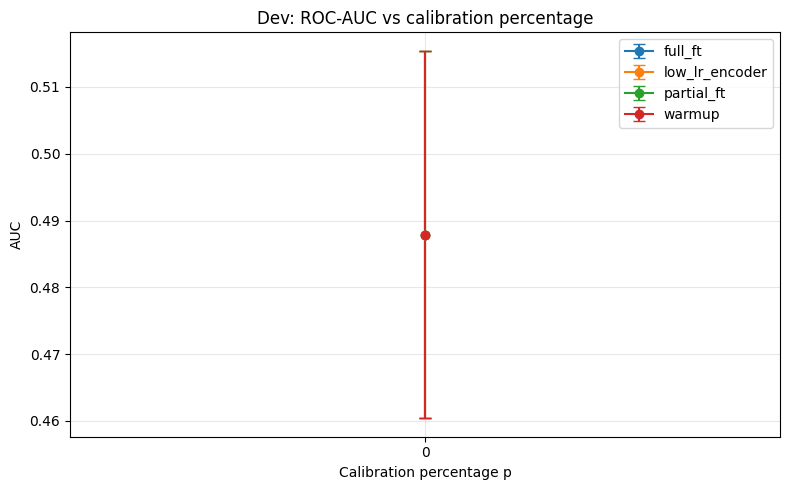

Saved: /kaggle/working/stage5_block2_results/stage5_final_eval_dev_ft_strategies/plots/f1_vs_p_ft_strategies_dev.png


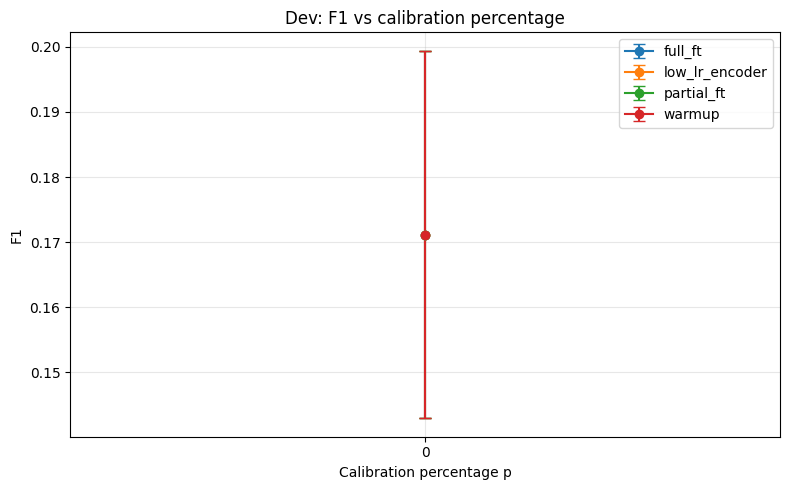

In [61]:
# =========================
# Main plots
# =========================

plot_metric_vs_p(
    agg_df=agg_df,
    metric="auc",
    save_path=PLOTS_DIR / "roc_auc_vs_p_ft_strategies_dev.png",
    title="Dev: ROC-AUC vs calibration percentage",
)

plot_metric_vs_p(
    agg_df=agg_df,
    metric="f1",
    save_path=PLOTS_DIR / "f1_vs_p_ft_strategies_dev.png",
    title="Dev: F1 vs calibration percentage",
)

Saved: /kaggle/working/stage5_block2_results/stage5_final_eval_dev_ft_strategies/plots/accuracy_vs_p_ft_strategies_dev.png


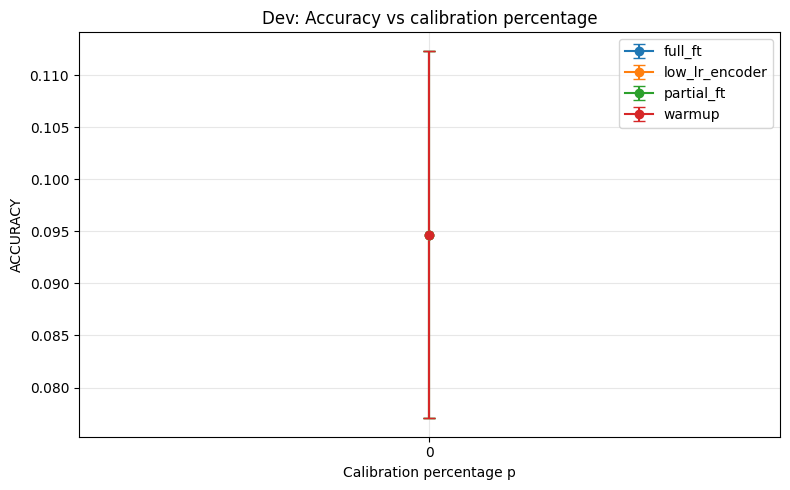

Saved: /kaggle/working/stage5_block2_results/stage5_final_eval_dev_ft_strategies/plots/fdr_vs_p_ft_strategies_dev.png


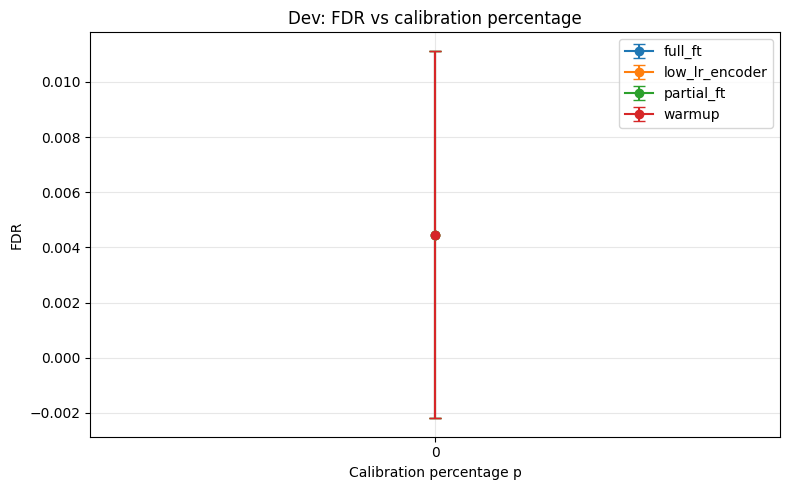

In [62]:
plot_metric_vs_p(
    agg_df=agg_df,
    metric="accuracy",
    save_path=PLOTS_DIR / "accuracy_vs_p_ft_strategies_dev.png",
    title="Dev: Accuracy vs calibration percentage",
)

plot_metric_vs_p(
    agg_df=agg_df,
    metric="fdr",
    save_path=PLOTS_DIR / "fdr_vs_p_ft_strategies_dev.png",
    title="Dev: FDR vs calibration percentage",
)

In [63]:
# =========================
# Pretty pivot tables
# =========================

auc_pivot = agg_df.pivot(
    index="p",
    columns="ft_strategy",
    values="auc_mean",
).sort_index()

f1_pivot = agg_df.pivot(
    index="p",
    columns="ft_strategy",
    values="f1_mean",
).sort_index()

display(auc_pivot)
display(f1_pivot)

auc_pivot.to_csv(TABLES_DIR / "pivot_auc_mean.csv")
f1_pivot.to_csv(TABLES_DIR / "pivot_f1_mean.csv")

ft_strategy,full_ft,low_lr_encoder,partial_ft,warmup
p,,,,
0,0.487901,0.487901,0.487901,0.487901


ft_strategy,full_ft,low_lr_encoder,partial_ft,warmup
p,,,,
0,0.171181,0.171181,0.171181,0.171181


In [64]:
# =========================
# Mean ± std tables
# =========================

def make_mean_std_table(agg_df: pd.DataFrame, metric: str) -> pd.DataFrame:
    tmp = agg_df[["p", "ft_strategy", f"{metric}_mean", f"{metric}_std"]].copy()
    tmp["value"] = tmp.apply(
        lambda row: f"{row[f'{metric}_mean']:.4f} ± {row[f'{metric}_std']:.4f}"
        if pd.notnull(row[f"{metric}_std"])
        else f"{row[f'{metric}_mean']:.4f}",
        axis=1,
    )
    out = tmp.pivot(index="p", columns="ft_strategy", values="value").sort_index()
    return out

auc_mean_std = make_mean_std_table(agg_df, "auc")
f1_mean_std = make_mean_std_table(agg_df, "f1")

display(auc_mean_std)
display(f1_mean_std)

auc_mean_std.to_csv(TABLES_DIR / "auc_mean_pm_std.csv")
f1_mean_std.to_csv(TABLES_DIR / "f1_mean_pm_std.csv")

ft_strategy,full_ft,low_lr_encoder,partial_ft,warmup
p,,,,
0,0.4879 ± 0.0275,0.4879 ± 0.0275,0.4879 ± 0.0275,0.4879 ± 0.0275


ft_strategy,full_ft,low_lr_encoder,partial_ft,warmup
p,,,,
0,0.1712 ± 0.0282,0.1712 ± 0.0282,0.1712 ± 0.0282,0.1712 ± 0.0282


In [65]:
# print("FINAL_DEV_DIR:", FINAL_DEV_DIR)
# print("Group:", FINAL_DEV_CONFIG["group"])
# print("N subjects:", len(FINAL_DEV_CONFIG["subjects"]))
# print("p_list:", FINAL_DEV_CONFIG["p_list"])
# print("ft_strategy_list:", FINAL_DEV_CONFIG["ft_strategy_list"])
# print("lr_encoder:", FINAL_DEV_CONFIG["lr_encoder"])
# print("lr_head:", FINAL_DEV_CONFIG["lr_head"])
# print("weight_decay:", FINAL_DEV_CONFIG["weight_decay"])
# print("warmup_epochs:", FINAL_DEV_CONFIG["warmup_epochs"])